In [1]:
import matplotlib.pyplot as plt
import numpy as np

base_dir = "/home/kamrul/Documents/kamrul_files_Linux/OORT/ClusterFed_OORT/results/svhn2/"
oort_file = "output_svhn_oort_global_violation.txt"

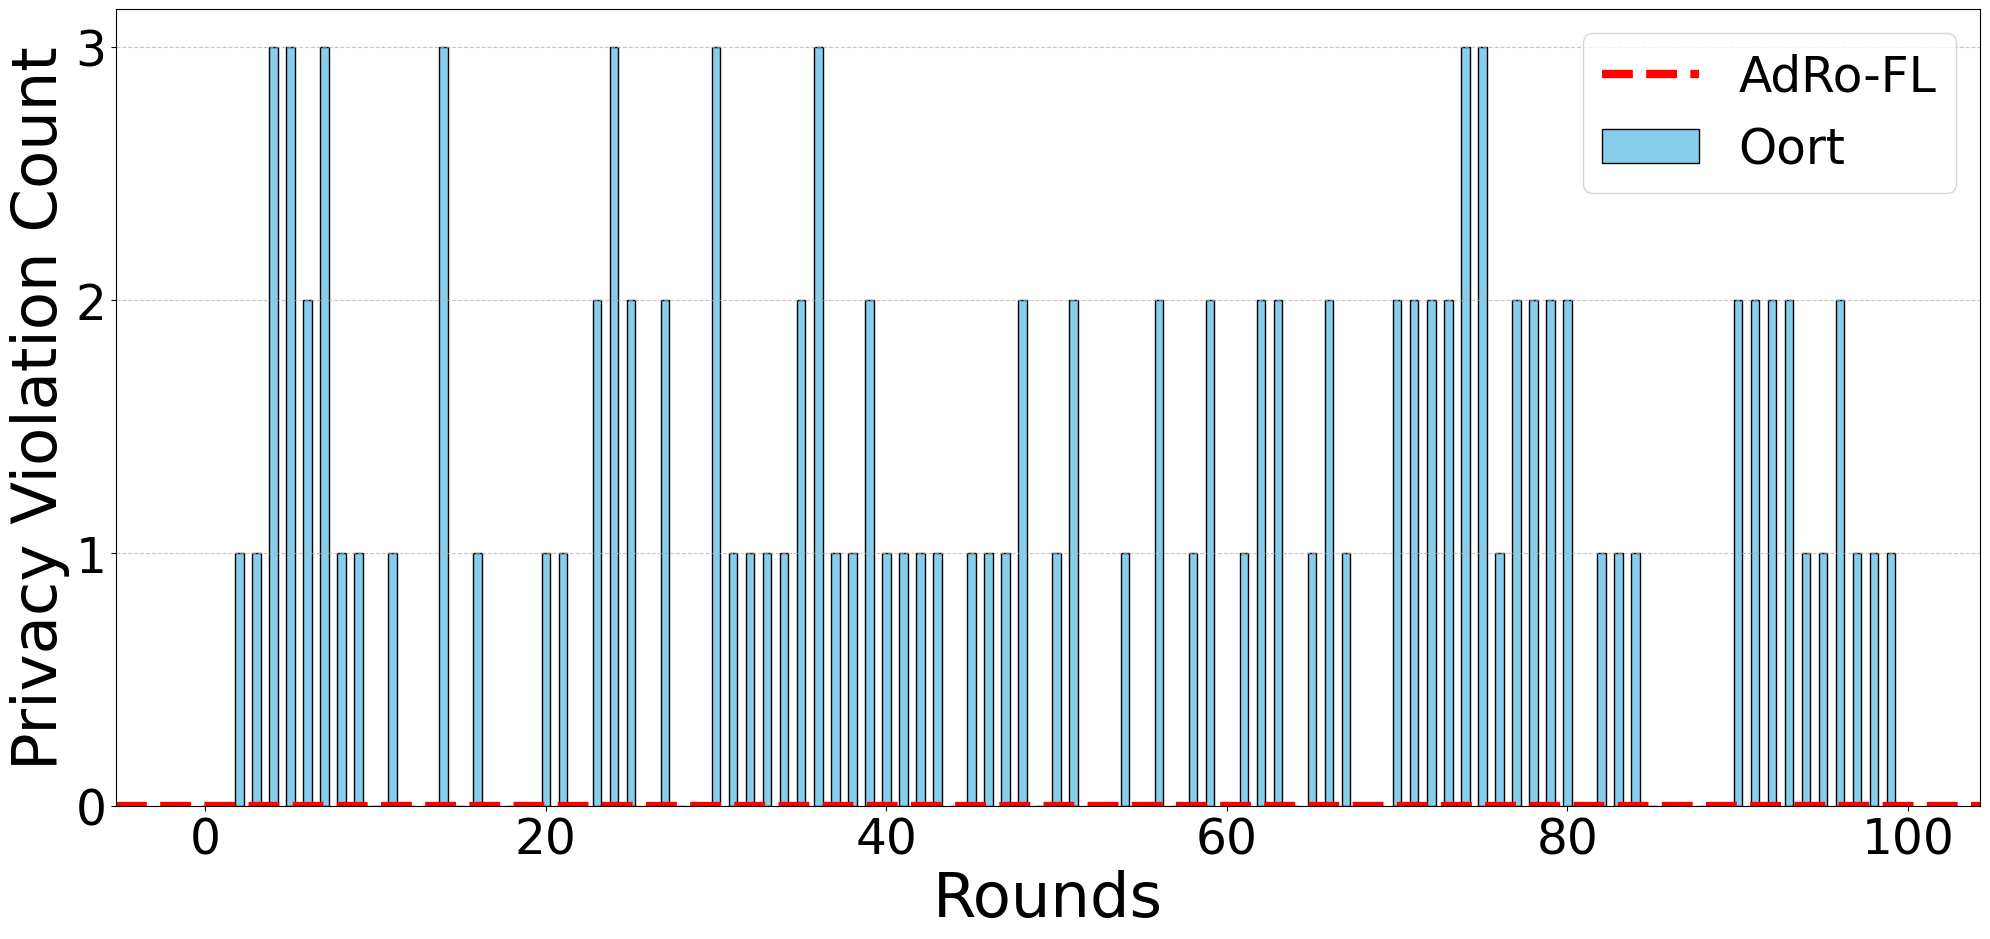

In [3]:
# Function to load data from file
def load_violation_count(file_name):
    data = {}
    with open(base_dir + file_name, "r") as f:
        exec(f.read(), {}, data)
    return data.get("violation_count", [])

# Load OORT violation count
oort_violations = load_violation_count(oort_file)
max_rounds = 100
rounds = np.array(range(min(len(oort_violations), max_rounds)))
oort_violations = oort_violations[:max_rounds]

# Proposed method (zero violations)
proposed_violations = np.zeros(len(rounds))

# Common font sizes
label_fontsize = 45
legend_fontsize = 35
tick_fontsize = 35

# Bar chart plotting
plt.figure(figsize=(20, 10))

bar_width = 0.5

# OORT violation bars
plt.bar(rounds, oort_violations, width=bar_width, color='skyblue', edgecolor='black', label='Oort')

# Proposed method (baseline at zero)
#plt.bar(rounds, proposed_violations, width=bar_width, color='red', alpha=0.6, edgecolor='black', label='Proposed Method')
# Proposed method baseline (visible bold line)
plt.axhline(0, color='red', linewidth=6, linestyle='--', label='AdRo-FL')

# Mark average violations clearly
#avg_violations = np.mean(oort_violations)
#plt.axhline(avg_violations, color='purple', linestyle='--', linewidth=2, label=f'Average Violations ({avg_violations:.2f})')

# Set plot details
plt.xlabel('Rounds', fontsize=label_fontsize)
plt.ylabel('Privacy Violation Count', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(np.arange(0, max(oort_violations) + 1, 1), fontsize=tick_fontsize)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legend outside the plot (top center)
plt.legend(fontsize=legend_fontsize, loc='upper right')

# Layout adjustment
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Display the plot
plt.show()
